In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from utils.validate_config import (
    load_yaml_config,
    require_config_directory,
)
from utils.iter_data import iter_metric_transform_frames
from utils.metric_anova import fit_anova, AnovaSpec
from utils.var_partition_plot import plot_anova_variance_partition

In [2]:
config = load_yaml_config("degradation_config.yaml")
analysis_dir = require_config_directory(config, "analysis_out_dir")

metadata_download_path = Path(".") / "metadata"
metadata_download_path.mkdir(parents=True, exist_ok=True)

platemap_dir = metadata_download_path / "platemaps"
platemap_files = sorted(path for path in platemap_dir.glob("*_platemap.csv"))
if not platemap_files:
    raise FileNotFoundError(f"No platemap CSV files found in {platemap_dir}.")
barcode_file = metadata_download_path / "Barcode_platemap_pilot_data.csv"
if not barcode_file.exists():
    raise FileNotFoundError(f"Barcode platemap CSV file not found: {barcode_file}")

metric_dir = output_dir = analysis_dir / "patches" / "metrics"
if not metric_dir.exists():
    raise FileNotFoundError(
        f"Metric directory {metric_dir} does not exist. "
        "Please run [] to generate the metrics before running this notebook."
    )
metric_subdirs = [d for d in metric_dir.iterdir() if d.is_dir()]
print(f"Found {len(metric_subdirs)} metric subdirectories:")
for subdir in metric_subdirs:
    print(f"  - {subdir.name}")

output_dir = Path(".") / "results" / "variance_partition_analysis"
output_dir.mkdir(parents=True, exist_ok=True)
plot_dir = output_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

Found 7 metric subdirectories:
  - psnr
  - dists
  - mae
  - foreground_ssim
  - lpips
  - foreground_psnr
  - ssim


In [3]:
barcode_df = pd.read_csv(barcode_file).rename(columns={'barcode': 'Metadata_Plate'})

platemap_df = pd.DataFrame()
for platemap in barcode_df['platemap_file'].unique():
    df = pd.read_csv(platemap_dir / f'{platemap}.csv')
    df['platemap_file'] = platemap
    platemap_df = pd.concat([platemap_df, df], ignore_index=True)
barcode_platemap_df = pd.merge(
    barcode_df, platemap_df, on='platemap_file', how='inner'
).rename(columns={'well': 'Metadata_Well'})

In [4]:
ANOVA_SPEC: AnovaSpec = {
    "dependent": "metric_value",
    "variables": {
        "cell_line": {"kind": "categorical"},
        "seeding_density": {"kind": "categorical"},
        "channel": {"kind": "categorical"},
        "parameter_value": {"kind": "continuous"},
    },
    "terms": (
        ("cell_line",),
        ("seeding_density",),
        ("channel",),
        ("cell_line", "seeding_density"),
        ("cell_line", "channel"),
        ("seeding_density", "channel"),
        ("parameter_value",),
        ("parameter_value", "seeding_density"),
        ("parameter_value", "cell_line"),
        ("parameter_value", "channel"),
    ),
    "anova_type": 2,
}

In [5]:
variance_results: list[pd.DataFrame] = []
max_invalid_prop = 0.2

for subdir, transform_name, df in iter_metric_transform_frames(
    metric_subdirs
):
    metric_name = subdir.name

    print(
        f"Processing metric={metric_name}, "
        f"transform={transform_name}, "
        f"rows={len(df):,}"
    )

    metric_values = df["metric_value"]
    invalid_mask = metric_values.isna() | ~np.isfinite(metric_values)
    if invalid_mask.any():
        # allow some invalid values for random_gamma transform + psnr, 
        # since the max gamma correction can overbrighten image and mess with PSNR
        if transform_name == "random_gamma" and metric_name in ["psnr", "foreground_psnr"]:
            pass
        elif metric_name in ["foreground_psnr", "foreground_ssim"]:
            pass
        elif invalid_mask.mean() > max_invalid_prop:
            print(
                f"Skipping metric={metric_name}, "
                f"transform={transform_name}: "
                f"metric_value contains {invalid_mask.sum():,} invalid values "
                f"({invalid_mask.mean():.2%} > {max_invalid_prop:.2%})."
            )
            continue
        else: # explicitly print unexpected low prop invalid values
            print(
                f"Unexpected invalid values encountered in metric={metric_name}, "
                f"transform={transform_name}: "
                f"metric_value contains {invalid_mask.sum():,} invalid values "
            )

        df = df.loc[~invalid_mask].copy()

    if df.empty:
        print(
            f"Skipping metric={metric_name}, "
            f"transform={transform_name}: "
            "no valid metric values remain."
        )
        continue

    df_enrich = df.merge(
        barcode_platemap_df,
        on=["Metadata_Plate", "Metadata_Well"],
        how="inner",
        validate="many_to_one",
    )

    if df_enrich.empty:
        print(
            f"Skipping metric={metric_name}, "
            f"transform={transform_name}: "
            "no rows remained after the platemap merge."
        )
        continue

    anova_result = fit_anova(
        df_enrich,
        ANOVA_SPEC,
        metadata={
            "metric_name": metric_name,
            "transform_name": transform_name,
        }
    )

    if anova_result is not None:
        variance_results.append(anova_result)

Processing metric=psnr, transform=dilate, rows=564,540
Processing metric=psnr, transform=erode, rows=564,540
Processing metric=psnr, transform=gauss_noise, rows=564,540
Processing metric=psnr, transform=gaussian_blur, rows=564,540
Processing metric=psnr, transform=grid_distortion, rows=564,540
Processing metric=psnr, transform=random_gamma, rows=564,540
Processing metric=dists, transform=dilate, rows=564,540
Processing metric=dists, transform=erode, rows=564,540
Processing metric=dists, transform=gauss_noise, rows=564,540
Processing metric=dists, transform=gaussian_blur, rows=564,540
Processing metric=dists, transform=grid_distortion, rows=564,540
Processing metric=dists, transform=random_gamma, rows=564,540
Processing metric=mae, transform=dilate, rows=564,540
Processing metric=mae, transform=erode, rows=564,540
Processing metric=mae, transform=gauss_noise, rows=564,540
Processing metric=mae, transform=gaussian_blur, rows=564,540
Processing metric=mae, transform=grid_distortion, rows=

In [6]:
if not variance_results:
    raise RuntimeError(
        "No valid metric/transform ANOVA results were produced."
    )

variance_partition_df = pd.concat(
    variance_results,
    ignore_index=True,
)

variance_partition_df = (
    variance_partition_df
    .sort_values(
        [
            "metric_name",
            "transform_name",
            "term",
        ]
    )
    .reset_index(drop=True)
)

variance_partition_df.to_parquet(
    output_dir / "variance_partition_results.parquet", index=False,
)

variance_partition_df.head()

,term,sum_sq,df,F,PR(>F),eta2,partial_eta2,n_obs,metric_name,transform_name,formula
0,Residual,1397.667874,564336.0,NaN,NaN,0.354645,NaN,564540,dists,dilate,Q('metric_value') ~ C(Q('cell_line')) + C(Q('s...
1,cell_line,160.122491,17.0,3803.095132,0.0,0.040630,0.102788,564540,dists,dilate,Q('metric_value') ~ C(Q('cell_line')) + C(Q('s...
2,cell_line:channel,13.613992,68.0,80.837029,0.0,0.003454,0.009647,564540,dists,dilate,Q('metric_value') ~ C(Q('cell_line')) + C(Q('s...
3,cell_line:seeding_density,316.004889,68.0,1876.370780,0.0,0.080183,0.184402,564540,dists,dilate,Q('metric_value') ~ C(Q('cell_line')) + C(Q('s...
4,channel,418.994708,4.0,42294.346536,0.0,0.106316,0.230640,564540,dists,dilate,Q('metric_value') ~ C(Q('cell_line')) + C(Q('s...


Saved figure to results/variance_partition_analysis/plots/anova.png


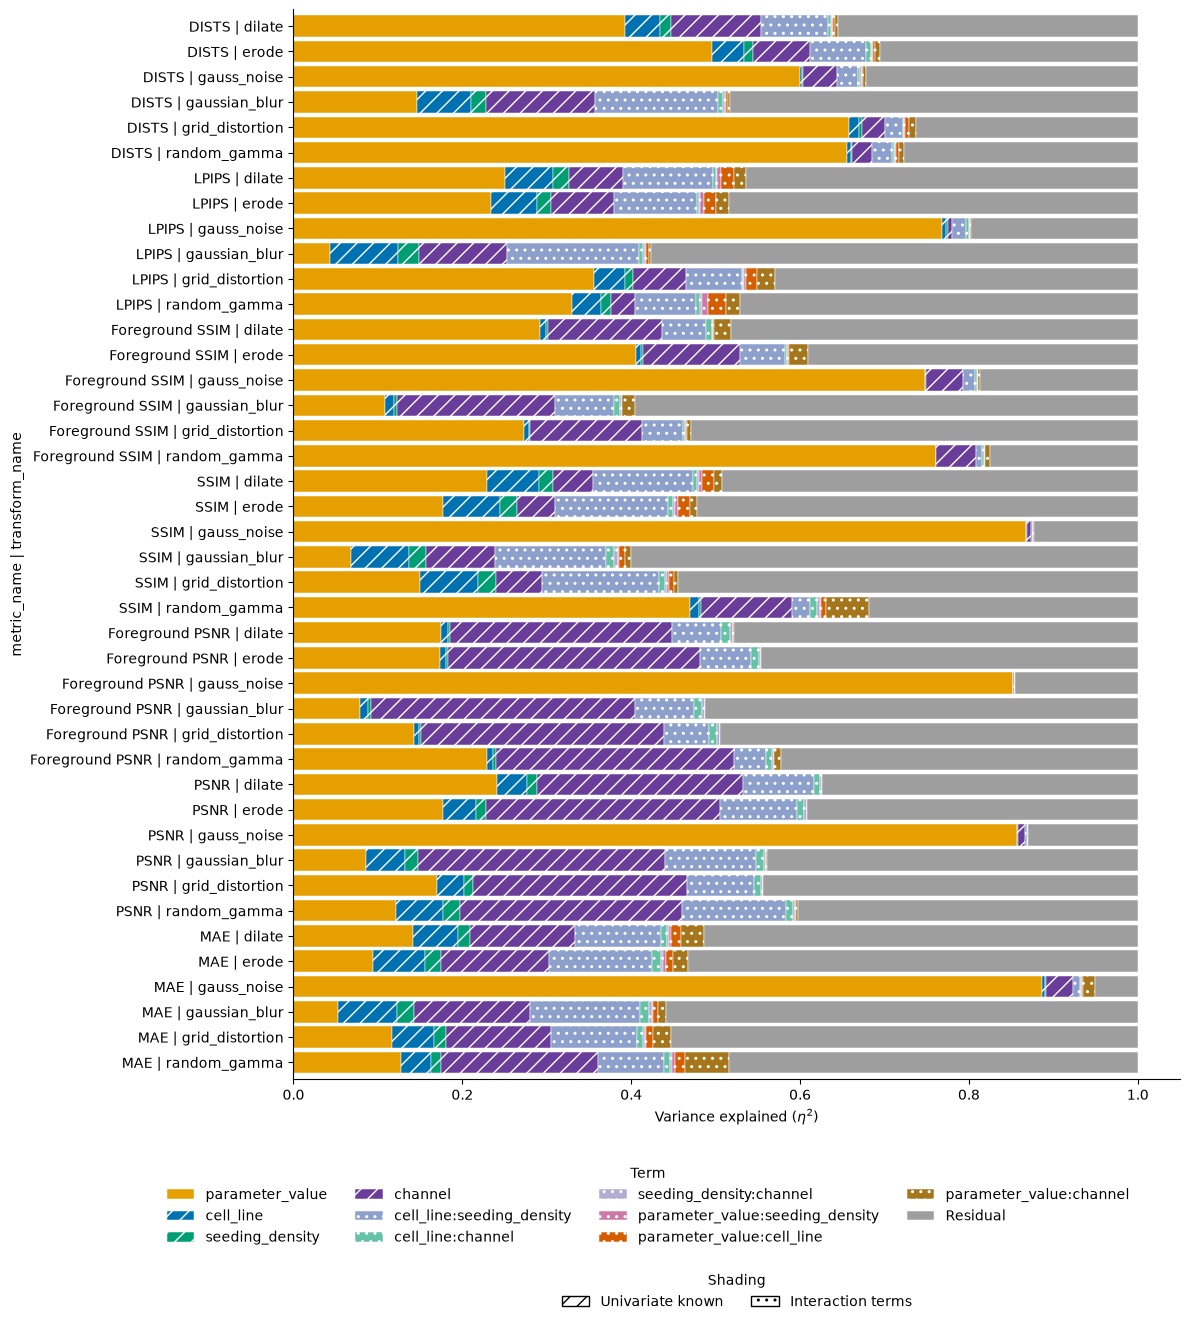

In [7]:
TERM_COLORS = {
    "parameter_value": "#E69F00",
    "cell_line": "#0072B2",
    "seeding_density": "#009E73",
    "channel": "#6A3D9A",
    "cell_line:seeding_density": "#8DA0CB",
    "cell_line:channel": "#66C2A5",
    "seeding_density:channel": "#B2ABD2",
    "parameter_value:cell_line": "#D55E00",
    "parameter_value:seeding_density": "#CC79A7",
    "parameter_value:channel": "#A6761D",
    "Residual": "#9E9E9E",
}

TERM_ORDER = [
    "parameter_value",
    "cell_line",
    "seeding_density",
    "channel",
    "cell_line:seeding_density",
    "cell_line:channel",
    "seeding_density:channel",
    "parameter_value:seeding_density",
    "parameter_value:cell_line",
    "parameter_value:channel",
    "Residual",
]

HATCH_GROUPS = {
    "Univariate known": (
        {
            "cell_line",
            "seeding_density",
            "channel",
        },
        "//",
    ),
    "Interaction terms": (
        {
            "cell_line:seeding_density",
            "cell_line:channel",
            "seeding_density:channel",
            "parameter_value:seeding_density",
            "parameter_value:cell_line",
            "parameter_value:channel",
        },
        "..",
    ),
}

METRIC_ORDER = [
    "dists",
    "lpips",
    "foreground_ssim",
    "ssim",
    "foreground_psnr",
    "psnr",
    "mae",
]


METRIC_LABELS = {
    "dists": "DISTS",
    "lpips": "LPIPS",
    "foreground_ssim": "Foreground SSIM",
    "ssim": "SSIM",
    "foreground_psnr": "Foreground PSNR",
    "psnr": "PSNR",
    "mae": "MAE",
}

fig, ax, plot_wide = plot_anova_variance_partition(
    variance_partition_df,
    row_cols=(
        "metric_name",
        "transform_name",
    ),
    value_col="eta2",
    term_order=TERM_ORDER,
    term_colors=TERM_COLORS,
    hatch_groups=HATCH_GROUPS,
    row_orders={
        "metric_name": METRIC_ORDER,
    },
    row_value_labels={
        "metric_name": METRIC_LABELS,
    },
    output_path=plot_dir / "anova.png",
    figsize_width=12,
    row_height=0.34,
)